SAM1 code based on https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
and https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

SAM2 code based on https://github.com/huggingface/segment-anything-2/blob/coreml-conversion/notebooks/image_predictor_example.ipynb
and https://github.com/huggingface/segment-anything-2/blob/coreml-conversion/notebooks/automatic_mask_generator_example.ipynb

In [7]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import torch

print("CHECKING DEVICES")
if torch.backends.mps.is_available():
   # device = torch.device("mps")
   device = torch.device("mps")
   # SAM still does not fix the problems related MPS till 2026.4.14
   print("MPS is ready")

elif torch.cuda.is_available():
   device = torch.device("cuda")
   print("CUDA is ready for use")

else:
   device = torch.device("cpu")
   print("CPU is ready for use")

print(f"Final device selected: {device}\n")

CHECKING DEVICES
CUDA is ready for use
Final device selected: cuda



In [2]:
# import other libraries that is neeeded
import cv2 as cv
import numpy as np
import scipy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

import warnings
warnings.filterwarnings("ignore")

In [3]:
# read and load the images
# change the path addresses if using the Colab or other devices
test_path = 'C:/Users/leolj/Desktop/9517-proj/EWS-Dataset/test'
train_path = 'C:/Users/leolj/Desktop/9517-proj/EWS-Dataset/train' 
val_path = 'C:/Users/leolj/Desktop/9517-proj/EWS-Dataset/validation'

def load_images(path):
    all_files = os.listdir(path)
    png_files = sorted([f for f in all_files if f.lower().endswith('.png')])
    # mask file are files end with "_mask.png"
    # filter out the original images
    image_files = [f for f in png_files if not f.lower().endswith('_mask.png')]

    images = []
    masks = []
    # filenames = []
    
    for fname in image_files:
        img_path = os.path.join(path, fname)
        
        mask_name = fname.replace('.png', '_mask.png')
        mask_path = os.path.join(path, mask_name)

        img = cv.imread(img_path, cv.IMREAD_COLOR)
        mask = cv.imread(mask_path, cv.IMREAD_GRAYSCALE)

        if img is not None and mask is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

            images.append(img)
            masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)

    return images, masks


# Load all sets
test_images, test_masks  = load_images(test_path)
train_images, train_masks = load_images(train_path)
val_images, val_masks = load_images(val_path)

print("Test images shape: ", test_images.shape, val_masks.shape)
print("Train images shape:", train_images.shape, train_masks.shape)
print("Validation images shape:  ", val_images.shape, test_masks.shape)

Test images shape:  (24, 350, 350, 3) (24, 350, 350)
Train images shape: (142, 350, 350, 3) (142, 350, 350)
Validation images shape:   (24, 350, 350, 3) (24, 350, 350)


In [4]:
def compute_metrics(pred_mask, gt_mask):
    pred = (pred_mask > 0).flatten()
    gt   = (gt_mask > 0).flatten()
    
    accuracy  = accuracy_score(gt, pred)
    precision = precision_score(gt, pred)
    recall = recall_score(gt, pred)
    f1 = f1_score(gt, pred)

    # Compute Intersection-over-Union between two binary mask
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    iou = intersection / union if union > 0 else 0.0
    
    return accuracy, precision, recall, f1, iou

In [6]:
# SAM 1
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [ ]:
# load the pre-trained model vit_b
# change the path where you store the checkpoint file
# choose a approprate vit model for your device

model_type = "vit_b" # base
sam_checkpoint = "C:/Users/leolj/Desktop/9517-proj/sam_vit_b_01ec64.pth"

#  MPS does not support float64, force to use float32
if str(device) == "mps":
    device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Model predicts the masks automaticly
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)

# run SAM automatic mask generation and return a binary mask
def predict_sam_mask(image):
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)
    masks = mask_generator.generate(image)

    if len(masks) == 0:
        return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    # conbine all instance masks
    combined = np.zeros((image.shape[0], image.shape[1]), dtype=bool)
    for m in masks:
        combined = np.logical_or(combined, m['segmentation'])

    return combined.astype(np.uint8) * 255

In [ ]:
def evaluation(images, gt_masks, set_name="Validation"):
    pred_masks = []
    for i, img in enumerate(images):
        pred = predict_sam_mask(img)
        pred_masks.append(pred)
    pred_masks = np.array(pred_masks)

    acc_list, prec_list, rec_list, f1_list, iou_list = [], [], [], [], []
    for pred, gt in zip(pred_masks, gt_masks):
        a, p, r, f, i = compute_metrics(pred, gt)
        acc_list.append(a)
        prec_list.append(p)
        rec_list.append(r)
        f1_list.append(f)
        iou_list.append(i)

    print(f"\nSAM (vit_b) Zero-Shot on {set_name}")
    print(f"Accuracy  : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall    : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    print(f"F1-score  : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"IoU       : {np.mean(iou_list):.4f} ± {np.std(iou_list):.4f}")
    return pred_masks

In [ ]:
# zero-shot evaluation on val
val_pred_masks = evaluation(val_images, val_masks, "Validation")


SAM (vit_b) Zero-Shot on Validation
Accuracy  : 0.6887 ± 0.2649
Precision : 0.6887 ± 0.2649
Recall    : 1.0000 ± 0.0000
F1-score  : 0.7837 ± 0.2045
IoU       : 0.6887 ± 0.2649


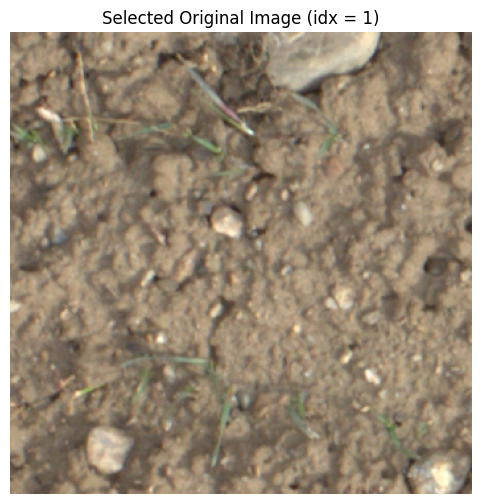

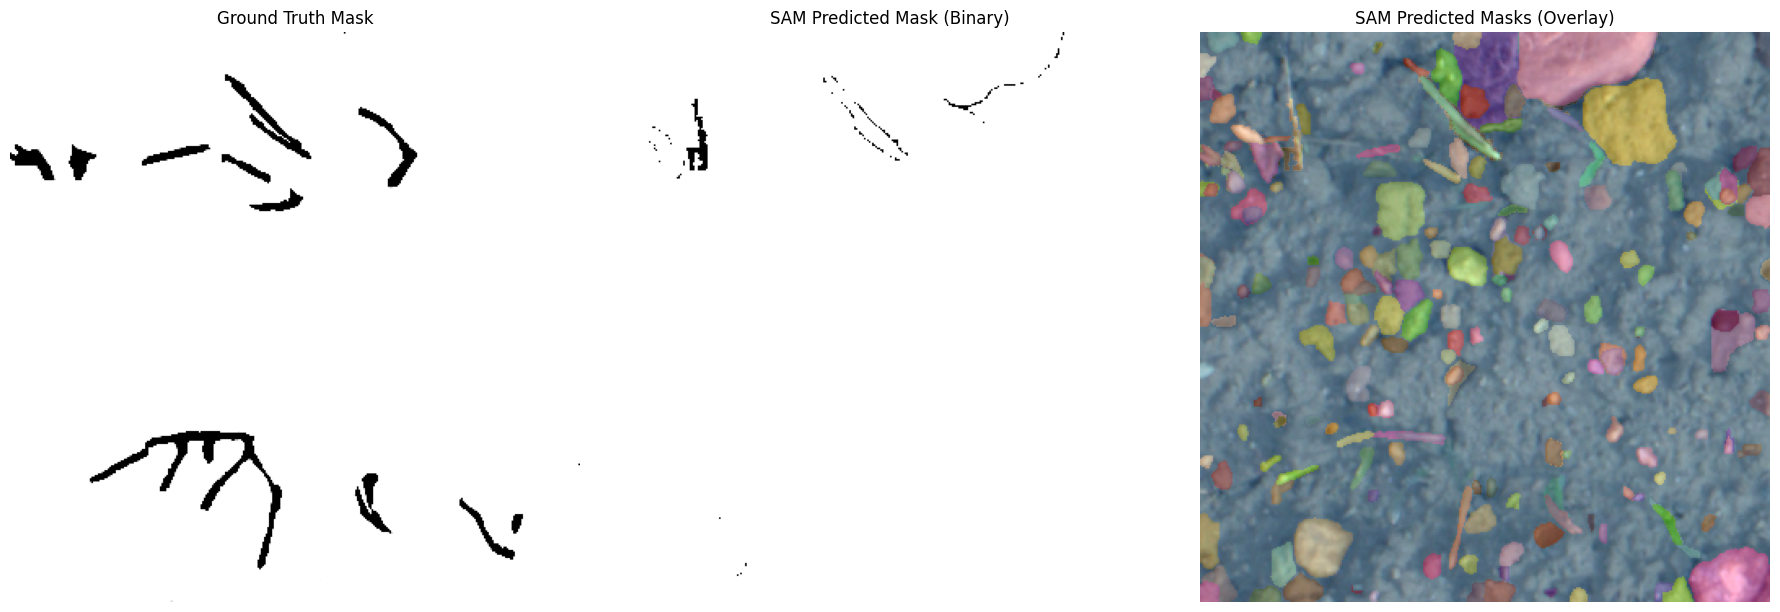

In [14]:
# compare the ground truth mask and predicted mask visually. 
# pick up an image randmly to compare
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

idx = random.randint(0, len(val_images)-1)
img = val_images[idx]
gt  = val_masks[idx]
pred = predict_sam_mask(img)

anns = mask_generator.generate(img.astype(np.uint8) if img.dtype != np.uint8 else img)
    
# display the chose picture
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Selected Original Image (idx = {idx})")
plt.axis('off')
plt.show()

# GT Mask vs Predicted Mask visually
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(gt, cmap='gray')
ax[0].set_title("Ground Truth Mask")
ax[0].axis('off')

ax[1].imshow(pred, cmap='gray')
ax[1].set_title("SAM Predicted Mask (Binary)")
ax[1].axis('off')

# overlay
ax[2].imshow(img)
show_anns(anns)
ax[2].set_title("SAM Predicted Masks (Overlay)")
ax[2].axis('off')

plt.tight_layout()
plt.show()